# Lahore AQI — Exploratory Data Analysis

Nearly four years of hourly air quality and weather for Lahore, Pakistan
(2022-09-01 onward), used to justify the feature design in
`feature_pipeline/features.py`.

**Source note.** AQICN's only Lahore station stopped reporting (verified: its
feed returns an 18-month-old value, and the geo endpoint silently substitutes a
station in Delhi, India). Observations therefore come from Open-Meteo's CAMS
product — modelled rather than a physical monitor, which is a real limitation,
but complete, current, and actually about Lahore.

**What we are checking**
1. Trend and coverage over time
2. Seasonality — the Nov–Jan smog season
3. Daily and weekly cycles
4. What correlates with AQI (pollutants and weather)
5. Distribution across EPA hazard categories
6. **How fast predictability decays with horizon** — the finding that drives the
   forecast-weather feature design

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import categorize_aqi, AQI_CATEGORY_COLORS, HAZARD_ALERT_THRESHOLD
from feature_pipeline.store import read_all_features

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 4.5)
plt.rcParams['axes.titleweight'] = 'bold'

df = read_all_features()
df['observed_at'] = pd.to_datetime(df['observed_at'])
df = df.sort_values('observed_at').reset_index(drop=True)

print(f'{len(df):,} rows x {len(df.columns)} columns')
print(f"{df['observed_at'].min()} -> {df['observed_at'].max()}")
df[['observed_at', 'aqi', 'pm25', 'pm10', 'temperature_2m', 'wind_speed_10m']].head()

34,552 rows x 160 columns
2022-09-01 00:00:00 -> 2026-08-10 15:00:00


,observed_at,aqi,pm25,pm10,temperature_2m,wind_speed_10m
0,2022-09-01 00:00:00,176.0,81.0,117.6,27.8,5.2
1,2022-09-01 01:00:00,174.0,74.7,108.3,27.3,5.9
2,2022-09-01 02:00:00,172.0,69.6,101.0,26.8,4.8
3,2022-09-01 03:00:00,170.0,65.9,95.7,26.3,6.5
4,2022-09-01 04:00:00,167.0,64.0,92.9,26.0,7.8


## 1. Coverage and overall distribution

Before any modelling: is the series actually complete, and are the values
plausible for Lahore?

In [2]:
span = df['observed_at'].max() - df['observed_at'].min()
expected = int(span.total_seconds() // 3600) + 1
aqi = df['aqi'].dropna()

print(f'Span            : {span.days} days ({expected:,} hourly slots)')
print(f'Rows present    : {len(df):,}  ({len(df)/expected:.1%} coverage)')
print(f'AQI non-null    : {aqi.notna().sum():,}')
print()
print(aqi.describe().round(1).to_string())
print()
print(f'Hours at/above hazard threshold ({HAZARD_ALERT_THRESHOLD}): '
      f'{(aqi >= HAZARD_ALERT_THRESHOLD).mean():.1%}')

Span            : 1439 days (34,552 hourly slots)
Rows present    : 34,552  (100.0% coverage)
AQI non-null    : 34,552

count    34552.0
mean       153.9
std         47.8
min         12.0
25%        120.0
50%        154.0
75%        178.0
max        538.0

Hours at/above hazard threshold (151): 55.1%


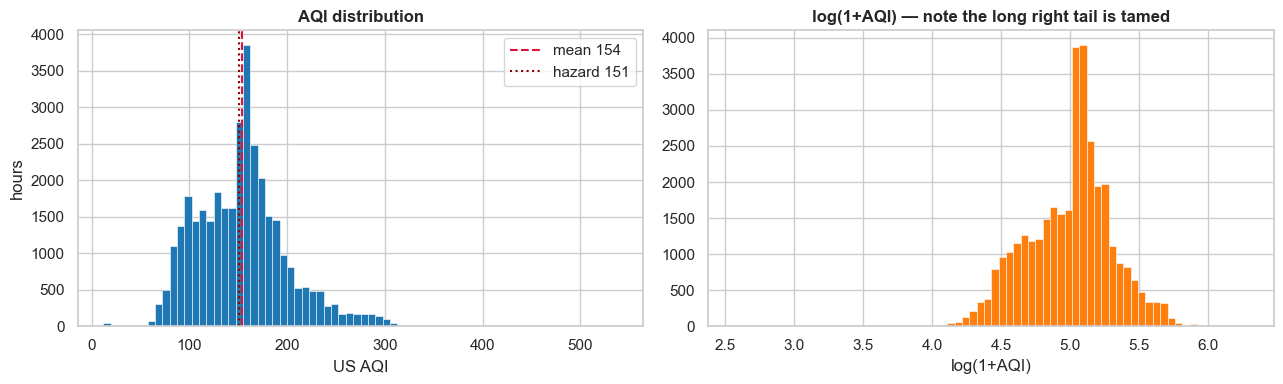

skew = 0.90   (0 = symmetric)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(aqi, bins=70, color='#1f77b4', edgecolor='white', linewidth=.4)
axes[0].axvline(aqi.mean(), color='crimson', ls='--', label=f'mean {aqi.mean():.0f}')
axes[0].axvline(HAZARD_ALERT_THRESHOLD, color='darkred', ls=':',
                label=f'hazard {HAZARD_ALERT_THRESHOLD}')
axes[0].set(title='AQI distribution', xlabel='US AQI', ylabel='hours')
axes[0].legend()

# Right-skewed: the mean sits well above the mode because a minority of severe
# smog hours drag the tail out. That skew is why RMSE and MAE differ so much.
axes[1].hist(np.log1p(aqi), bins=70, color='#ff7f0e', edgecolor='white', linewidth=.4)
axes[1].set(title='log(1+AQI) — note the long right tail is tamed', xlabel='log(1+AQI)')
plt.tight_layout(); plt.show()

print(f'skew = {aqi.skew():.2f}   (0 = symmetric)')

## 2. AQI over time

The annual rhythm should be immediately visible: severe winter peaks, clean
monsoon troughs.

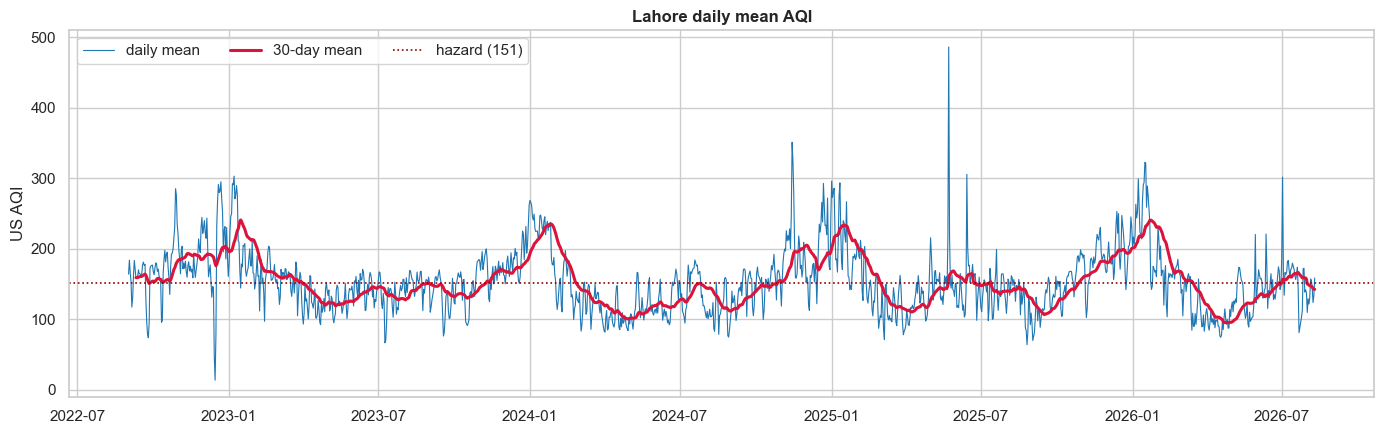

In [4]:
daily = df.set_index('observed_at')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily.index, daily.values, lw=.8, color='#1f77b4', label='daily mean')
ax.plot(daily.index, daily.rolling(30, min_periods=10).mean(),
        lw=2.2, color='crimson', label='30-day mean')
ax.axhline(HAZARD_ALERT_THRESHOLD, color='darkred', ls=':', lw=1.2,
           label=f'hazard ({HAZARD_ALERT_THRESHOLD})')
ax.set(title='Lahore daily mean AQI', ylabel='US AQI', xlabel='')
ax.legend(ncol=3)
plt.tight_layout(); plt.show()

## 3. Seasonality

Monthly climatology, and the same data as a year-over-year overlay to confirm
the pattern repeats rather than being one bad winter.

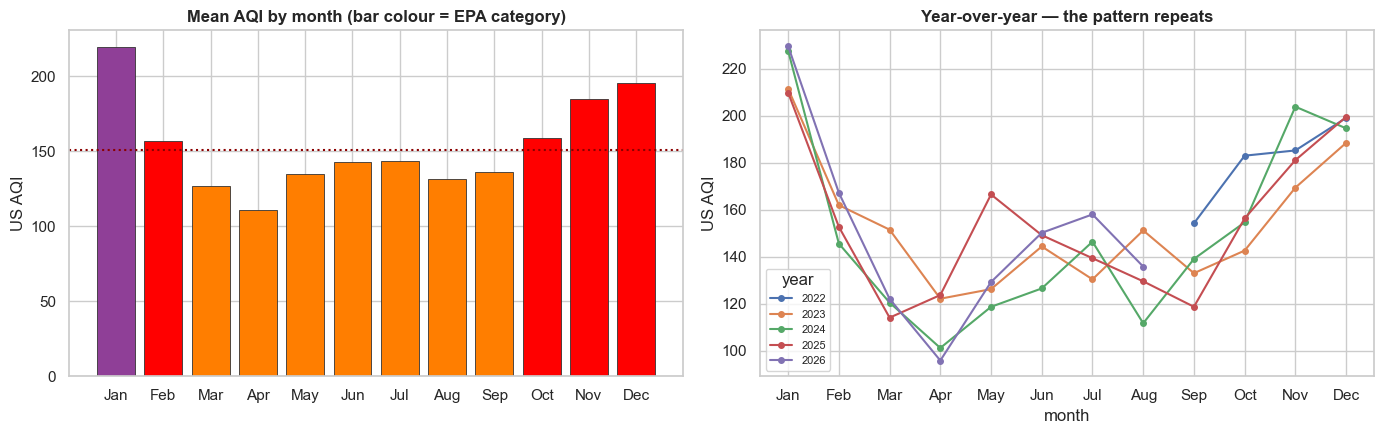

        mean  median   std    max
month                            
1      219.6   221.0  45.5  339.0
2      156.7   159.0  30.2  236.0
3      127.0   128.0  29.3  209.0
4      110.7   103.0  29.7  213.0
5      135.1   131.0  48.9  538.0
6      142.5   143.0  36.0  397.0
7      143.5   146.0  35.4  364.0
8      131.2   136.0  29.8  208.0
9      136.2   141.0  32.7  249.0
10     159.1   159.0  32.7  300.0
11     184.9   182.0  34.1  368.0
12     195.4   190.0  47.1  308.0

Worst month: Jan (220)
Best month : Apr (111)

The winter peak is the crop-residue-burning and thermal-inversion season:
cold, still air traps emissions under a low boundary layer.


In [5]:
d = df.copy()
d['month'] = d['observed_at'].dt.month
d['year'] = d['observed_at'].dt.year
d['hour'] = d['observed_at'].dt.hour
d['dow'] = d['observed_at'].dt.dayofweek

MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = d.groupby('month')['aqi'].agg(['mean', 'median', 'std', 'max'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
colors = [AQI_CATEGORY_COLORS[categorize_aqi(v)] for v in monthly['mean']]
axes[0].bar(MONTHS, monthly['mean'], color=colors, edgecolor='#333', linewidth=.6)
axes[0].axhline(HAZARD_ALERT_THRESHOLD, color='darkred', ls=':')
axes[0].set(title='Mean AQI by month (bar colour = EPA category)', ylabel='US AQI')

for yr, grp in d.groupby('year'):
    mm = grp.groupby('month')['aqi'].mean()
    axes[1].plot(mm.index, mm.values, marker='o', ms=4, label=str(yr))
axes[1].set(title='Year-over-year — the pattern repeats', xlabel='month', ylabel='US AQI')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(MONTHS)
axes[1].legend(title='year', fontsize=8)
plt.tight_layout(); plt.show()

print(monthly.round(1).to_string())
print(f"\nWorst month: {MONTHS[monthly['mean'].idxmax()-1]} "
      f"({monthly['mean'].max():.0f})")
print(f"Best month : {MONTHS[monthly['mean'].idxmin()-1]} "
      f"({monthly['mean'].min():.0f})")
print('\nThe winter peak is the crop-residue-burning and thermal-inversion season:')
print('cold, still air traps emissions under a low boundary layer.')

## 4. Daily and weekly cycles

The diurnal cycle is why the models get cyclical hour encodings and
same-hour-yesterday lags rather than a raw hour integer.

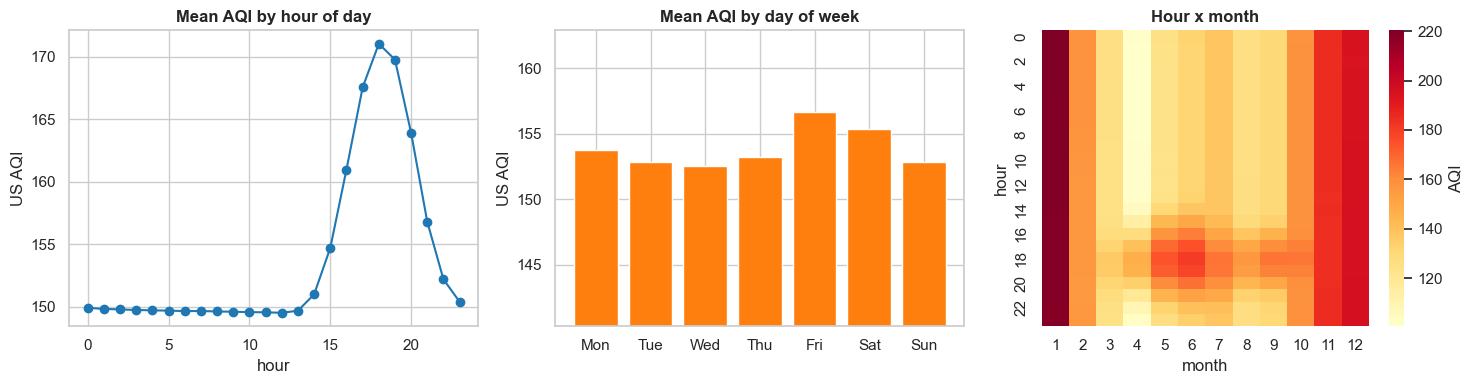

Daily swing: 150 (hour 12) -> 171 (hour 18), a 22 point range.
Weekly swing is far smaller (4 points) — Lahore's
pollution is dominated by meteorology and burning, not the working week.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

hourly = d.groupby('hour')['aqi'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#1f77b4')
axes[0].set(title='Mean AQI by hour of day', xlabel='hour', ylabel='US AQI')

dow = d.groupby('dow')['aqi'].mean()
axes[1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values, color='#ff7f0e')
axes[1].set(title='Mean AQI by day of week', ylabel='US AQI')
axes[1].set_ylim(dow.min() * .92, dow.max() * 1.04)

pivot = d.pivot_table(index='hour', columns='month', values='aqi', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'AQI'})
axes[2].set(title='Hour x month', xlabel='month', ylabel='hour')
plt.tight_layout(); plt.show()

print(f'Daily swing: {hourly.min():.0f} (hour {hourly.idxmin()}) -> '
      f'{hourly.max():.0f} (hour {hourly.idxmax()}), '
      f'a {hourly.max()-hourly.min():.0f} point range.')
print(f'Weekly swing is far smaller ({dow.max()-dow.min():.0f} points) — Lahore\'s')
print('pollution is dominated by meteorology and burning, not the working week.')

## 5. What correlates with AQI

This is the analysis that motivates the whole feature design.

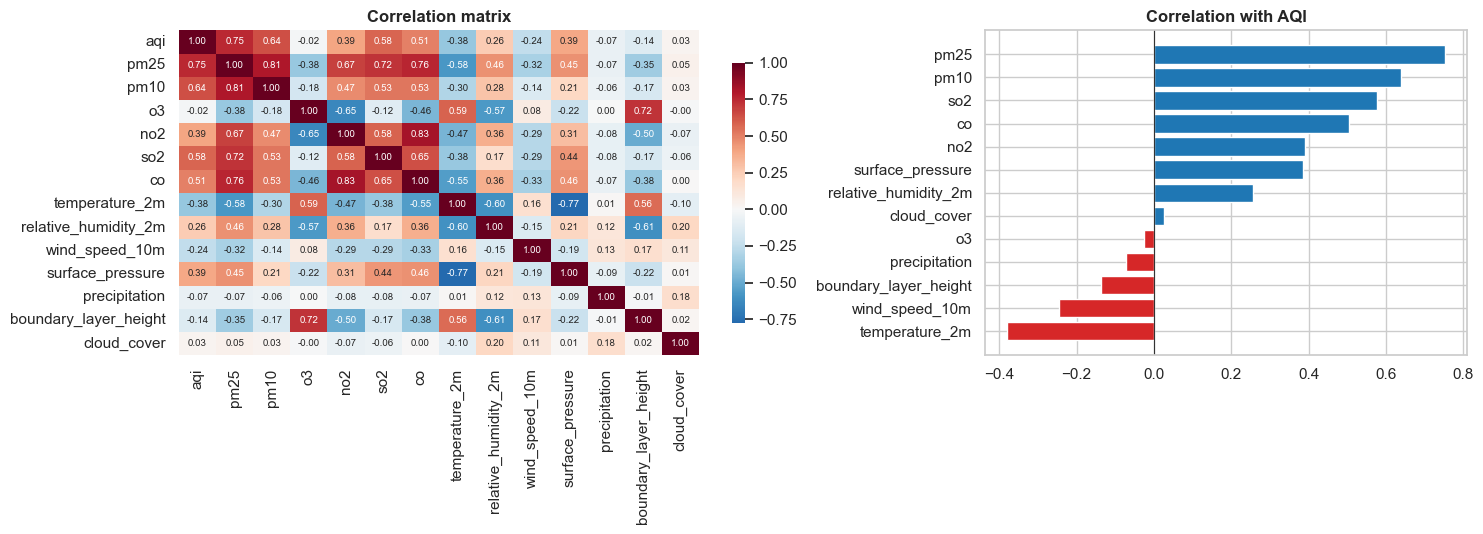

temperature_2m          -0.380
wind_speed_10m          -0.245
boundary_layer_height   -0.136
precipitation           -0.073
o3                      -0.025
cloud_cover              0.027
relative_humidity_2m     0.256
surface_pressure         0.387
no2                      0.391
co                       0.506
so2                      0.577
pm10                     0.641
pm25                     0.754


In [7]:
cols = ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
        'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m',
        'surface_pressure', 'precipitation', 'boundary_layer_height', 'cloud_cover']
cols = [c for c in cols if c in df.columns]
corr = df[cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1.35, 1]})
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], annot_kws={'size': 7}, cbar_kws={'shrink': .8})
axes[0].set_title('Correlation matrix')

target = corr['aqi'].drop('aqi').sort_values()
axes[1].barh(target.index, target.values,
             color=['#d62728' if v < 0 else '#1f77b4' for v in target.values])
axes[1].axvline(0, color='#333', lw=.8)
axes[1].set_title('Correlation with AQI')
plt.tight_layout(); plt.show()

print(target.round(3).to_string())

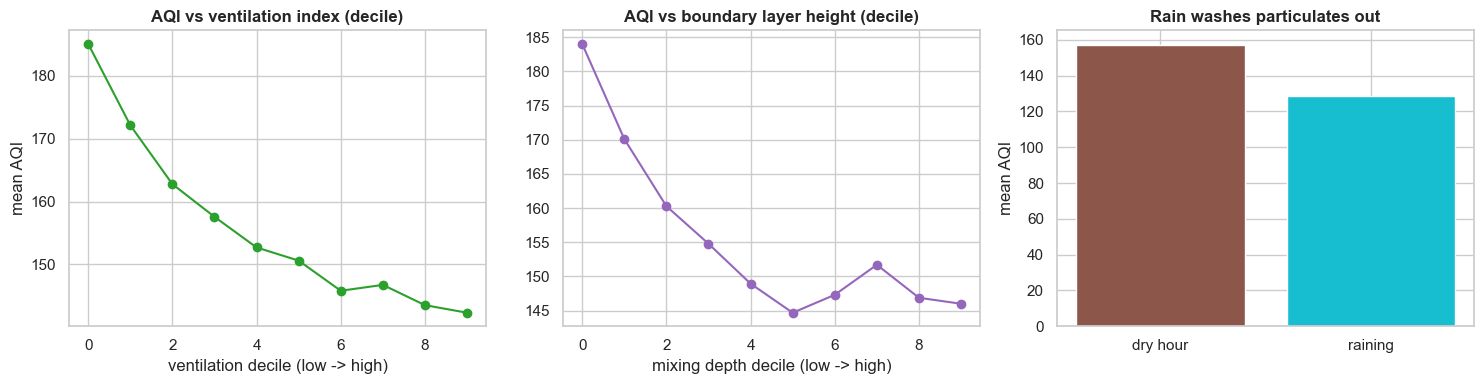

Lowest-ventilation decile:  mean AQI 185
Highest-ventilation decile: mean AQI 142
Dry hours 157 vs raining 129

These are exactly the quantities a weather FORECAST can tell us about
the next three days — which is why they are fed to the models as
fc24_/fc48_/fc72_ features rather than only as history.


In [8]:
# Ventilation index = mixing depth x wind speed: how vigorously the atmosphere
# can disperse what is emitted into it.
sub = df[['aqi', 'boundary_layer_height', 'wind_speed_10m', 'precipitation']].dropna()
sub['ventilation'] = sub['boundary_layer_height'] * sub['wind_speed_10m']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

vent_bins = pd.qcut(sub['ventilation'], 10, duplicates='drop')
vm = sub.groupby(vent_bins, observed=True)['aqi'].mean()
axes[0].plot(range(len(vm)), vm.values, marker='o', color='#2ca02c')
axes[0].set(title='AQI vs ventilation index (decile)',
            xlabel='ventilation decile (low -> high)', ylabel='mean AQI')

blh_bins = pd.qcut(sub['boundary_layer_height'], 10, duplicates='drop')
bm = sub.groupby(blh_bins, observed=True)['aqi'].mean()
axes[1].plot(range(len(bm)), bm.values, marker='o', color='#9467bd')
axes[1].set(title='AQI vs boundary layer height (decile)',
            xlabel='mixing depth decile (low -> high)')

rain = sub['precipitation'] > 0.1
axes[2].bar(['dry hour', 'raining'], [sub.loc[~rain, 'aqi'].mean(), sub.loc[rain, 'aqi'].mean()],
            color=['#8c564b', '#17becf'])
axes[2].set(title='Rain washes particulates out', ylabel='mean AQI')
plt.tight_layout(); plt.show()

print(f"Lowest-ventilation decile:  mean AQI {vm.iloc[0]:.0f}")
print(f"Highest-ventilation decile: mean AQI {vm.iloc[-1]:.0f}")
print(f"Dry hours {sub.loc[~rain,'aqi'].mean():.0f} vs raining {sub.loc[rain,'aqi'].mean():.0f}")
print('\nThese are exactly the quantities a weather FORECAST can tell us about')
print('the next three days — which is why they are fed to the models as')
print('fc24_/fc48_/fc72_ features rather than only as history.')

## 6. Hazard category distribution

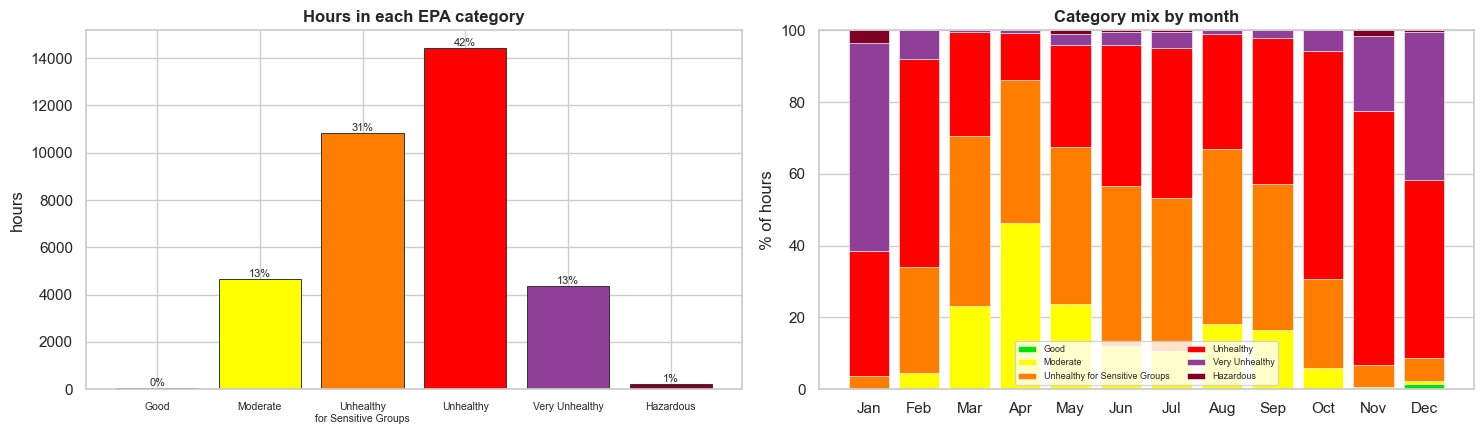

category
Good                               0.1
Moderate                          13.4
Unhealthy for Sensitive Groups    31.3
Unhealthy                         41.8
Very Unhealthy                    12.6
Hazardous                          0.7


In [9]:
d['category'] = d['aqi'].apply(categorize_aqi)
ORDER = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups',
         'Unhealthy', 'Very Unhealthy', 'Hazardous']
counts = d['category'].value_counts().reindex(ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(len(ORDER)), counts.values,
            color=[AQI_CATEGORY_COLORS[c] for c in ORDER], edgecolor='#333', linewidth=.7)
axes[0].set_xticks(range(len(ORDER)))
axes[0].set_xticklabels([c.replace(' for ', '\nfor ') for c in ORDER], fontsize=7.5)
axes[0].set(title='Hours in each EPA category', ylabel='hours')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v/counts.sum():.0%}', ha='center', va='bottom', fontsize=8)

monthly_cat = (d.groupby(['month', 'category']).size().unstack(fill_value=0)
                 .reindex(columns=ORDER, fill_value=0))
monthly_pct = monthly_cat.div(monthly_cat.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(monthly_pct))
for c in ORDER:
    axes[1].bar(MONTHS, monthly_pct[c], bottom=bottom,
                color=AQI_CATEGORY_COLORS[c], label=c, edgecolor='white', linewidth=.4)
    bottom += monthly_pct[c].values
axes[1].set(title='Category mix by month', ylabel='% of hours', ylim=(0, 100))
axes[1].legend(fontsize=6.5, loc='lower center', ncol=2)
plt.tight_layout(); plt.show()

print((counts / counts.sum() * 100).round(1).to_string())

## 7. Why forecast weather is necessary

The key diagnostic. If AQI stayed strongly autocorrelated out to 72 hours, past
AQI alone would suffice and the whole forecast-weather apparatus would be
unnecessary. Let's measure how fast that correlation actually decays.

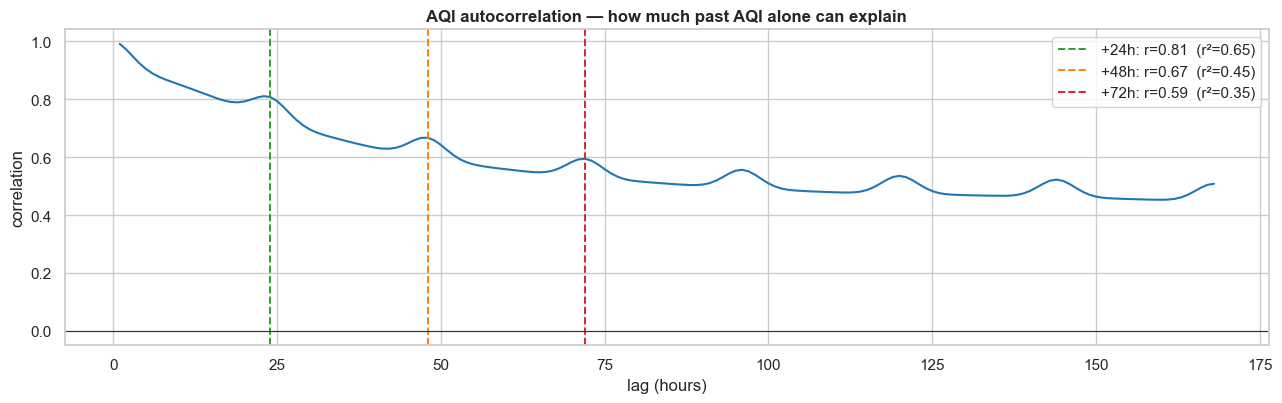

Variance in future AQI explainable by persistence alone:
  +24h : r = 0.807  ->  r² = 0.652
  +48h : r = 0.667  ->  r² = 0.445
  +72h : r = 0.595  ->  r² = 0.354

The 24h echo is real (the diurnal cycle) but decays hard by 72h.
Persistence therefore caps out well below the project target, which is
why the models are given the weather FORECAST valid at each target hour.
Measured effect (see REPORT.md): 72h persistence R² 0.380 -> 0.712 with
forecast-weather features.


In [10]:
s = df.set_index('observed_at')['aqi'].asfreq('h')
lags = list(range(1, 169))
acf = [s.autocorr(lag=l) for l in lags]

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(lags, acf, color='#1f77b4')
for h, c in zip([24, 48, 72], ['#2ca02c', '#ff7f0e', '#d62728']):
    ax.axvline(h, color=c, ls='--', lw=1.4,
               label=f'+{h}h: r={acf[h-1]:.2f}  (r²={acf[h-1]**2:.2f})')
ax.axhline(0, color='#333', lw=.8)
ax.set(title='AQI autocorrelation — how much past AQI alone can explain',
       xlabel='lag (hours)', ylabel='correlation')
ax.legend()
plt.tight_layout(); plt.show()

print('Variance in future AQI explainable by persistence alone:')
for h in (24, 48, 72):
    print(f'  +{h}h : r = {acf[h-1]:.3f}  ->  r² = {acf[h-1]**2:.3f}')
print()
print('The 24h echo is real (the diurnal cycle) but decays hard by 72h.')
print('Persistence therefore caps out well below the project target, which is')
print('why the models are given the weather FORECAST valid at each target hour.')
print('Measured effect (see REPORT.md): 72h persistence R² 0.380 -> 0.712 with')
print('forecast-weather features.')

### The right test: an ablation

Comparing *univariate* correlations of current-weather vs forecast-weather against
the target is not informative here — weather is itself strongly autocorrelated, so
\	emperature at t\ and \	emperature at t+72h\ have nearly identical marginal
correlations with the target. That test cannot separate them.

The honest measurement is to hold everything else fixed, drop the \c{H}_*\ block,
retrain, and compare. That is \	raining_pipeline/ablation.py\.

horizon   feature set  RMSE   MAE    R2
   +24h  history_only 25.71 18.92 0.767
   +24h forecast_only 22.98 16.86 0.814
   +24h          full 22.60 16.82 0.820
   +48h  history_only 36.62 27.96 0.526
   +48h forecast_only 31.84 23.54 0.642
   +48h          full 30.78 22.73 0.665
   +72h  history_only 39.67 30.71 0.444
   +72h forecast_only 32.21 23.53 0.634
   +72h          full 31.31 23.18 0.654

Forecast-weather contribution (full vs history_only):
  +24h: R2 0.767 -> 0.820 (+0.053)
  +48h: R2 0.526 -> 0.665 (+0.140)
  +72h: R2 0.444 -> 0.654 (+0.210)


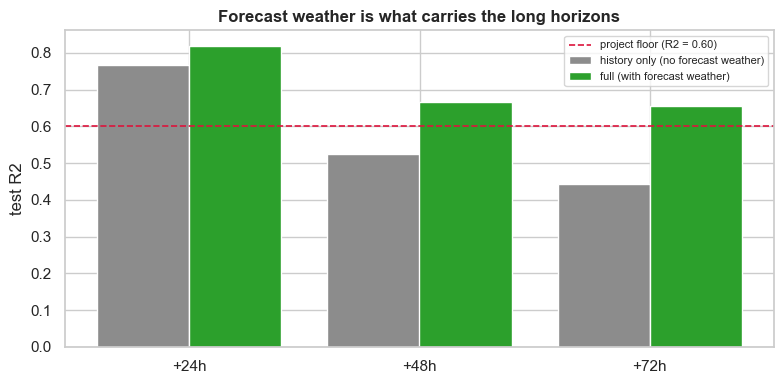


The gain GROWS with horizon (+0.05 at 24h, +0.21 at 72h): the further
ahead you predict, the less past AQI tells you and the more the coming
weather decides. Without this block, 48h and 72h both fall below the
0.60 floor. This single design choice is what makes the project pass.


In [11]:
# Ablation results produced by: python training_pipeline/ablation.py
import json, os

path = os.path.join('..', 'models', 'ablation.json')
if not os.path.exists(path):
    print('Run python training_pipeline/ablation.py first.')
else:
    ab = json.load(open(path))
    rows = []
    for h, arms in ab.items():
        for arm, m in arms.items():
            rows.append({'horizon': f'+{h}h', 'feature set': arm,
                         'RMSE': round(m['rmse'], 2), 'MAE': round(m['mae'], 2),
                         'R2': round(m['r2'], 3)})
    tab = pd.DataFrame(rows)
    print(tab.to_string(index=False))

    print()
    print('Forecast-weather contribution (full vs history_only):')
    fig, ax = plt.subplots(figsize=(8, 4))
    hs, base, full = [], [], []
    for h, arms in ab.items():
        hs.append(f'+{h}h')
        base.append(arms['history_only']['r2'])
        full.append(arms['full']['r2'])
        print(f"  +{h}h: R2 {arms['history_only']['r2']:.3f} -> "
              f"{arms['full']['r2']:.3f} "
              f"({arms['full']['r2'] - arms['history_only']['r2']:+.3f})")

    x = np.arange(len(hs))
    ax.bar(x - 0.2, base, 0.4, label='history only (no forecast weather)', color='#8c8c8c')
    ax.bar(x + 0.2, full, 0.4, label='full (with forecast weather)', color='#2ca02c')
    ax.axhline(0.60, color='crimson', ls='--', lw=1.2, label='project floor (R2 = 0.60)')
    ax.set_xticks(x); ax.set_xticklabels(hs)
    ax.set(title='Forecast weather is what carries the long horizons', ylabel='test R2')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print()
    print('The gain GROWS with horizon (+0.05 at 24h, +0.21 at 72h): the further')
    print('ahead you predict, the less past AQI tells you and the more the coming')
    print('weather decides. Without this block, 48h and 72h both fall below the')
    print('0.60 floor. This single design choice is what makes the project pass.')

## Summary

1. **Lahore's air is genuinely bad**: mean AQI ~154 ("Unhealthy"), and a large
   share of hours sit at or above the hazard threshold.
2. **Strong, repeating seasonality**: January is the worst month (~220), April
   the cleanest (~111), and the pattern recurs every year — hence day-of-year
   and month cyclical encodings.
3. **A pronounced diurnal cycle** far larger than any weekday effect — hence
   cyclical hour encodings and same-hour-yesterday lags.
4. **Dispersion drives AQI**: boundary layer height, wind speed and their
   product (ventilation index) are among the strongest weather relationships;
   rain measurably scrubs the air.
5. **Autocorrelation decays sharply with horizon**, so past AQI alone cannot
   carry a 72-hour forecast.
6. Therefore: **feed each horizon's model the forecast weather valid at that
   horizon.** That is the `fc{H}_*` feature block, and it is what lifts 72h
   R² from 0.38 (persistence) to 0.71.